In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import ttest_ind

sns.set(style="whitegrid")

In [2]:
df= pd.read_csv("/kaggle/input/eeg-psychiatric-disorders-dataset/EEG.machinelearing_data_BRMH.csv")
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,no.,sex,age,eeg.date,education,IQ,main.disorder,specific.disorder,AB.A.delta.a.FP1,AB.A.delta.b.FP2,...,COH.F.gamma.o.Pz.p.P4,COH.F.gamma.o.Pz.q.T6,COH.F.gamma.o.Pz.r.O1,COH.F.gamma.o.Pz.s.O2,COH.F.gamma.p.P4.q.T6,COH.F.gamma.p.P4.r.O1,COH.F.gamma.p.P4.s.O2,COH.F.gamma.q.T6.r.O1,COH.F.gamma.q.T6.s.O2,COH.F.gamma.r.O1.s.O2
0,1,M,57.0,2012.8.30,NaN,NaN,Addictive disorder,Alcohol use disorder,35.998557,21.717375,...,55.989192,16.739679,23.452271,45.678820,30.167520,16.918761,48.850427,9.422630,34.507082,28.613029
1,2,M,37.0,2012.9.6,6.0,120.0,Addictive disorder,Alcohol use disorder,13.425118,11.002916,...,45.595619,17.510824,26.777368,28.201062,57.108861,32.375401,60.351749,13.900981,57.831848,43.463261
2,3,M,32.0,2012.9.10,16.0,113.0,Addictive disorder,Alcohol use disorder,29.941780,27.544684,...,99.475453,70.654171,39.131547,69.920996,71.063644,38.534505,69.908764,27.180532,64.803155,31.485799
3,4,M,35.0,2012.10.8,18.0,126.0,Addictive disorder,Alcohol use disorder,21.496226,21.846832,...,59.986561,63.822201,36.478254,47.117006,84.658376,24.724096,50.299349,35.319695,79.822944,41.141873
4,5,M,36.0,2012.10.18,16.0,112.0,Addictive disorder,Alcohol use disorder,37.775667,33.607679,...,61.462720,59.166097,51.465531,58.635415,80.685608,62.138436,75.888749,61.003944,87.455509,70.531662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,M,22.0,2014.8.28,13.0,116.0,Healthy control,Healthy control,41.851823,36.771496,...,82.905657,34.850706,63.970519,63.982003,51.244725,62.203684,62.062237,31.013031,31.183413,98.325230
941,942,M,26.0,2014.9.19,13.0,118.0,Healthy control,Healthy control,18.986856,19.401387,...,65.917918,66.700117,44.756285,49.787513,98.905995,54.021304,93.902401,52.740396,92.807331,56.320868
942,943,M,26.0,2014.9.27,16.0,113.0,Healthy control,Healthy control,28.781317,32.369230,...,61.040959,27.632209,45.552852,33.638817,46.690983,19.382928,41.050717,7.045821,41.962451,19.092111
943,944,M,24.0,2014.9.20,13.0,107.0,Healthy control,Healthy control,19.929100,25.196375,...,99.113664,48.328934,41.248470,28.192238,48.665743,42.007147,28.735945,27.176500,27.529522,20.028446


In [3]:
def dfinfo (df):
    print(df.shape)
    print(df.info())
    print(df.isnull().sum())
 
dfinfo(df)

(945, 1149)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Columns: 1149 entries, no. to COH.F.gamma.r.O1.s.O2
dtypes: float64(1144), int64(1), object(4)
memory usage: 8.3+ MB
None
no.                       0
sex                       0
age                       0
eeg.date                  0
education                15
                         ..
COH.F.gamma.p.P4.r.O1     0
COH.F.gamma.p.P4.s.O2     0
COH.F.gamma.q.T6.r.O1     0
COH.F.gamma.q.T6.s.O2     0
COH.F.gamma.r.O1.s.O2     0
Length: 1149, dtype: int64


In [4]:
df.isnull().sum()

no.                       0
sex                       0
age                       0
eeg.date                  0
education                15
                         ..
COH.F.gamma.p.P4.r.O1     0
COH.F.gamma.p.P4.s.O2     0
COH.F.gamma.q.T6.r.O1     0
COH.F.gamma.q.T6.s.O2     0
COH.F.gamma.r.O1.s.O2     0
Length: 1149, dtype: int64

In [5]:
df.isnull().sum().sort_values(ascending=False).head(10)


Unnamed: 122            945
education                15
IQ                       13
no.                       0
COH.D.beta.j.Cz.m.T5      0
COH.D.beta.j.Cz.s.O2      0
COH.D.beta.j.Cz.r.O1      0
COH.D.beta.j.Cz.q.T6      0
COH.D.beta.j.Cz.p.P4      0
COH.D.beta.j.Cz.o.Pz      0
dtype: int64

In [6]:
df = df.loc[:, df.columns.notna()]       # remove columns with NaN names
df = df.loc[:, df.columns != '']         # remove columns with empty string names
df['education'] = df['education'].fillna(df['education'].median())
df['IQ'] = df['IQ'].fillna(df['IQ'].median())

In [7]:
df['eeg.date'] = pd.to_datetime(df['eeg.date'], errors='coerce')
df['eeg_year'] = df['eeg.date'].dt.year
df['eeg_month'] = df['eeg.date'].dt.month


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


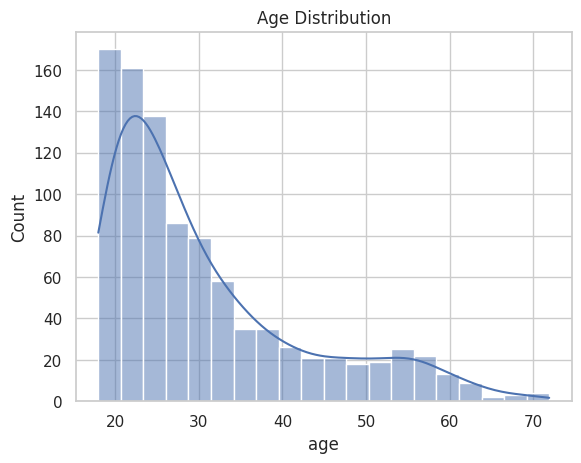

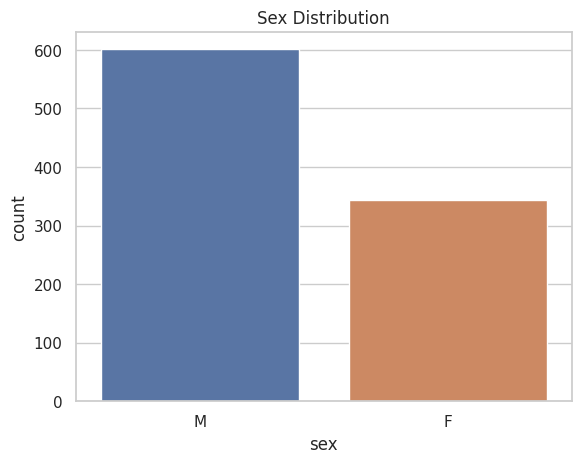

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


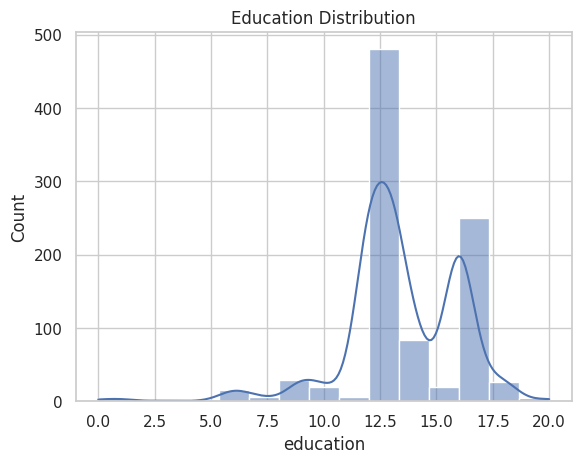

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


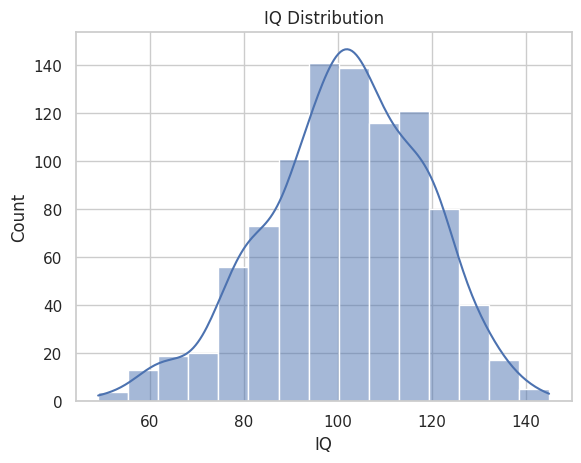

In [8]:
# Age distribution
sns.histplot(df['age'], kde=True, bins=20)
plt.title("Age Distribution")
plt.show()

# Sex distribution
sns.countplot(data=df, x='sex')
plt.title("Sex Distribution")
plt.show()

# Education distribution
sns.histplot(df['education'], kde=True, bins=15)
plt.title("Education Distribution")
plt.show()

# IQ distribution
sns.histplot(df['IQ'], kde=True, bins=15)
plt.title("IQ Distribution")
plt.show()


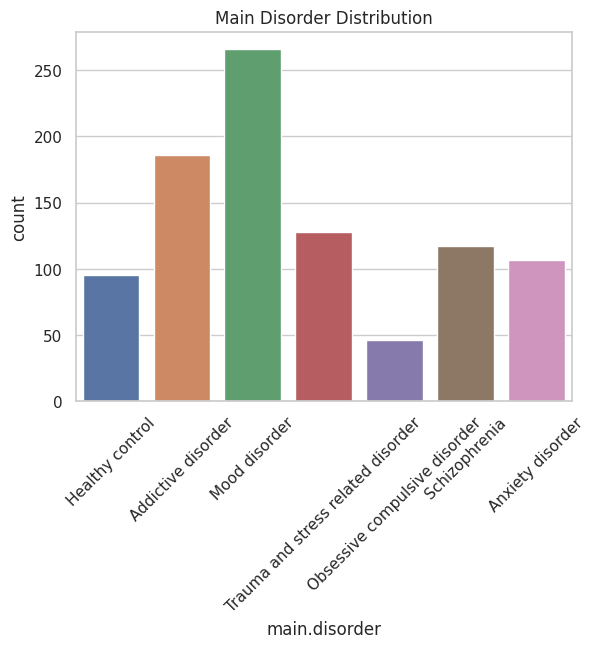

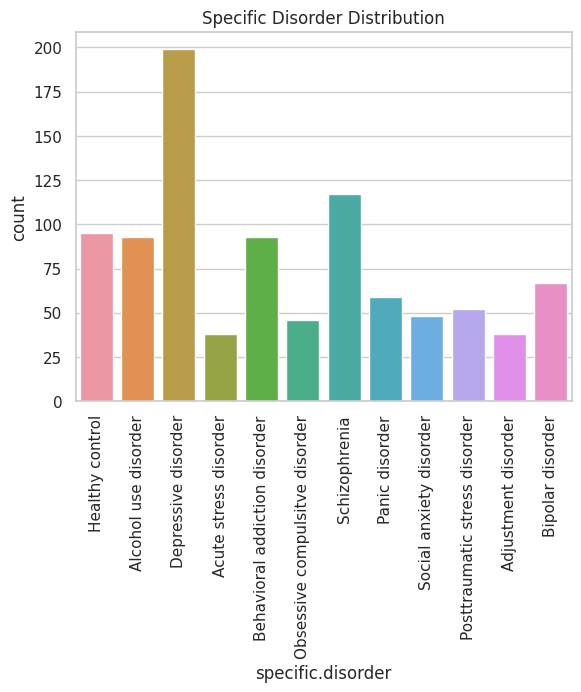

In [9]:
main_order = ['Healthy control', 'Addictive disorder', 'Mood disorder',
              'Trauma and stress related disorder', 'Obsessive compulsive disorder',
              'Schizophrenia', 'Anxiety disorder']

specific_order = ['Healthy control', 'Alcohol use disorder', 'Depressive disorder',
                  'Acute stress disorder', 'Behavioral addiction disorder',
                  'Obsessive compulsitve disorder', 'Schizophrenia', 'Panic disorder',
                  'Social anxiety disorder', 'Posttraumatic stress disorder',
                  'Adjustment disorder', 'Bipolar disorder']

# Only include valid categories
df_main_plot = df[df['main.disorder'].isin(main_order)]
df_specific_plot = df[df['specific.disorder'].isin(specific_order)]

# Plot
sns.countplot(data=df_main_plot, x='main.disorder', order=main_order)
plt.xticks(rotation=45)
plt.title("Main Disorder Distribution")
plt.show()

sns.countplot(data=df_specific_plot, x='specific.disorder', order=specific_order)
plt.xticks(rotation=90)
plt.title("Specific Disorder Distribution")
plt.show()


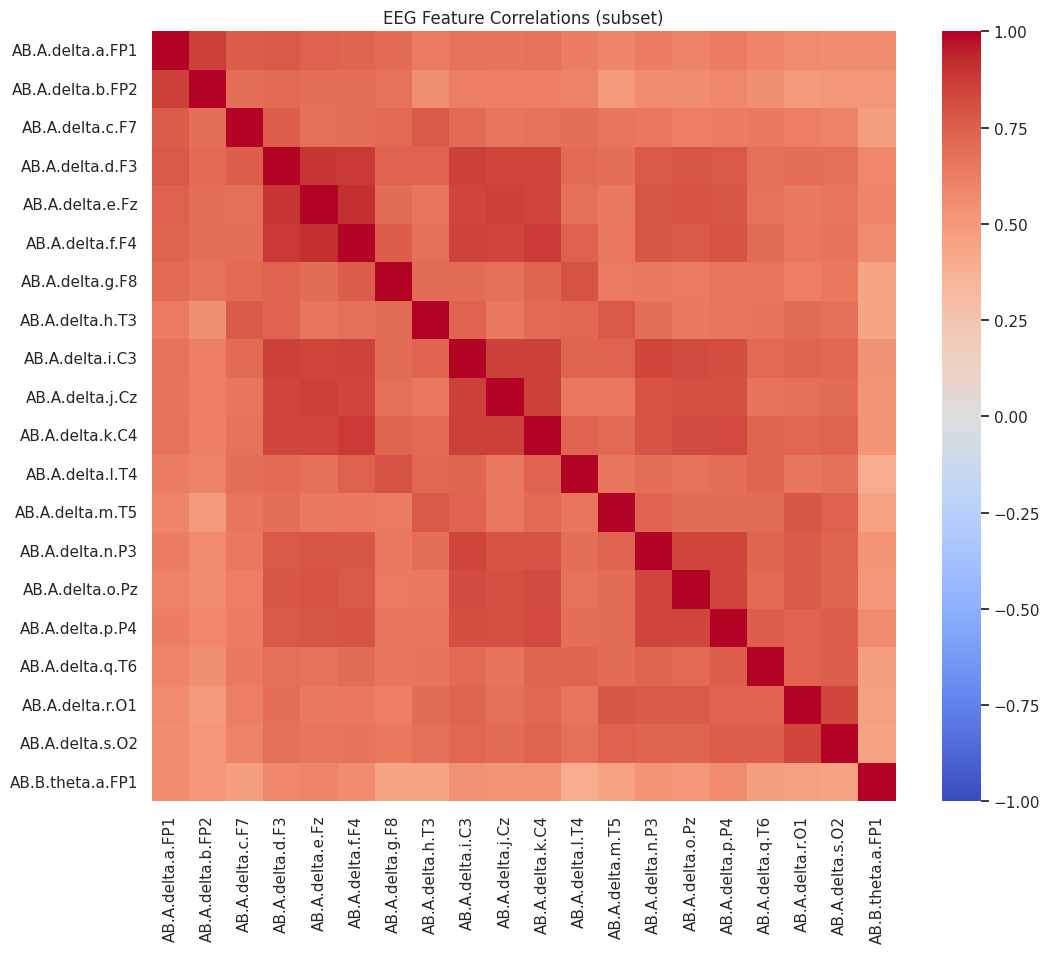

In [10]:
eeg_features = df.filter(regex='AB|COH')
corr_matrix = eeg_features.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix.iloc[:20,:20], cmap='coolwarm', vmin=-1, vmax=1)
plt.title("EEG Feature Correlations (subset)")
plt.show()


In [11]:
healthy = df[df['main.disorder'] == 'Healthy control']
addictive = df[df['main.disorder'] == 'Addictive disorder']

# T-tests for all EEG features
ttest_results = {}
for col in eeg_features.columns:
    stat, p = ttest_ind(healthy[col], addictive[col])
    ttest_results[col] = p

# Convert to DataFrame and sort by smallest p-value
ttest_df = pd.DataFrame.from_dict(ttest_results, orient='index', columns=['p_value']).sort_values('p_value')
print("Top 10 significant EEG features between Healthy vs Addictive:\n", ttest_df.head(10))

Top 10 significant EEG features between Healthy vs Addictive:
                          p_value
COH.A.delta.m.T5.n.P3   0.000002
COH.B.theta.m.T5.n.P3   0.000018
COH.A.delta.e.Fz.f.F4   0.000086
COH.A.delta.p.P4.q.T6   0.000099
COH.B.theta.p.P4.q.T6   0.000178
COH.A.delta.a.FP1.e.Fz  0.000179
COH.A.delta.a.FP1.f.F4  0.000179
COH.C.alpha.n.P3.p.P4   0.000439
COH.C.alpha.p.P4.q.T6   0.000507
COH.B.theta.a.FP1.e.Fz  0.000544


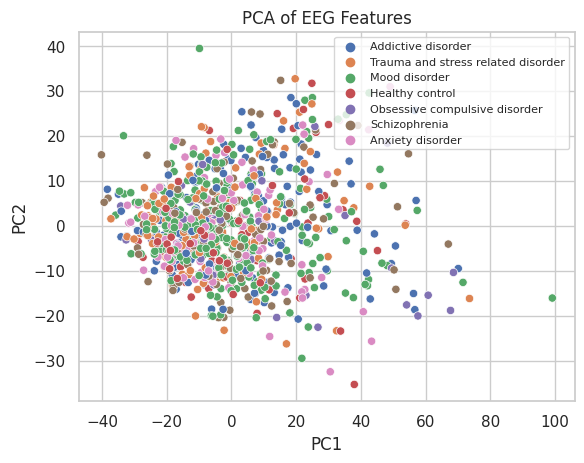

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(eeg_features)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['group'] = df['main.disorder']

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='group')
plt.title("PCA of EEG Features")
plt.legend(fontsize=8, loc='best')  # smaller font
plt.show()


In [13]:
ml_df = df[df['main.disorder'].isin(['Healthy control','Addictive disorder'])]
X = ml_df.filter(regex='AB|COH')
y = ml_df['main.disorder'].map({'Healthy control':0, 'Addictive disorder':1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Top 20 feature importances
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
print("Top 20 EEG Features by Importance:\n", feat_imp)

Accuracy: 0.6842105263157895
              precision    recall  f1-score   support

           0       1.00      0.25      0.40        24
           1       0.65      1.00      0.79        33

    accuracy                           0.68        57
   macro avg       0.82      0.62      0.59        57
weighted avg       0.80      0.68      0.62        57

Top 20 EEG Features by Importance:
 COH.D.beta.a.FP1.b.FP2        0.007987
COH.B.theta.m.T5.n.P3         0.007635
COH.B.theta.a.FP1.b.FP2       0.007048
COH.D.beta.m.T5.s.O2          0.006882
COH.C.alpha.e.Fz.n.P3         0.006331
COH.D.beta.b.FP2.d.F3         0.005998
COH.E.highbeta.a.FP1.b.FP2    0.005774
COH.B.theta.f.F4.g.F8         0.005759
COH.C.alpha.f.F4.n.P3         0.005188
COH.A.delta.f.F4.g.F8         0.005112
COH.D.beta.e.Fz.f.F4          0.005042
COH.E.highbeta.h.T3.m.T5      0.004814
COH.D.beta.k.C4.n.P3          0.004261
COH.C.alpha.a.FP1.d.F3        0.004240
COH.A.delta.a.FP1.b.FP2       0.004130
COH.A.delta.e.Fz.g.F8  